In [27]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

man <- read_csv('/kaggle/input/man-vs-women-matches/men_results.csv')
woman <- read_csv('/kaggle/input/man-vs-women-matches/women_results.csv')

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

New names:
• `` -> `...1`
Rows: 44353 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): home_team, away_team, tournament
dbl  (3): ...1, home_score, away_score
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 4884 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): home_team, away_team, tournament
dbl  (3): ...1, home_score, away_score
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
colnames(man)

[1] "...1"       "date"       "home_team"  "away_team"  "home_score"
[6] "away_score" "tournament"

In [12]:
head(man)
head(woman)

...1,date,home_team,away_team,home_score,away_score,tournament
<dbl>,<date>,<chr>,<chr>,<dbl>,<dbl>,<chr>
0,1872-11-30,Scotland,England,0,0,Friendly
1,1873-03-08,England,Scotland,4,2,Friendly
2,1874-03-07,Scotland,England,2,1,Friendly
3,1875-03-06,England,Scotland,2,2,Friendly
4,1876-03-04,Scotland,England,3,0,Friendly
5,1876-03-25,Scotland,Wales,4,0,Friendly


...1,date,home_team,away_team,home_score,away_score,tournament
<dbl>,<date>,<chr>,<chr>,<dbl>,<dbl>,<chr>
0,1969-11-01,Italy,France,1,0,Euro
1,1969-11-01,Denmark,England,4,3,Euro
2,1969-11-02,England,France,2,0,Euro
3,1969-11-02,Italy,Denmark,3,1,Euro
4,1975-08-25,Thailand,Australia,3,2,AFC Championship
5,1975-08-25,Hong Kong,New Zealand,0,2,AFC Championship


In [28]:
# Remove the first column (...1)
man <- man %>% select(-...1)
woman <- woman %>% select(-...1)

In [21]:
# Check for missing values
print(colSums(is.na(man)))
print(colSums(is.na(man)))

      date  home_team  away_team home_score away_score tournament 
         0          0          0          0          0          0 
      date  home_team  away_team home_score away_score tournament 
         0          0          0          0          0          0 


In [22]:
# Check for duplicate values
print(sum(duplicated(man)))
print(sum(duplicated(woman)))

[1] 0
[1] 0


In [23]:
# Check for structure
print(str(man))
print(str(woman))

tibble [44,353 × 6] (S3: tbl_df/tbl/data.frame)
 $ date      : Date[1:44353], format: "1872-11-30" "1873-03-08" ...
 $ home_team : chr [1:44353] "Scotland" "England" "Scotland" "England" ...
 $ away_team : chr [1:44353] "England" "Scotland" "England" "Scotland" ...
 $ home_score: num [1:44353] 0 4 2 2 3 4 1 0 7 9 ...
 $ away_score: num [1:44353] 0 2 1 2 0 0 3 2 2 0 ...
 $ tournament: chr [1:44353] "Friendly" "Friendly" "Friendly" "Friendly" ...
NULL
tibble [4,884 × 6] (S3: tbl_df/tbl/data.frame)
 $ date      : Date[1:4884], format: "1969-11-01" "1969-11-01" ...
 $ home_team : chr [1:4884] "Italy" "Denmark" "England" "Italy" ...
 $ away_team : chr [1:4884] "France" "England" "France" "Denmark" ...
 $ home_score: num [1:4884] 1 4 2 3 3 0 3 3 3 0 ...
 $ away_score: num [1:4884] 0 3 0 1 2 2 0 0 0 2 ...
 $ tournament: chr [1:4884] "Euro" "Euro" "Euro" "Euro" ...
NULL


In [31]:
# remove negative scores
man <- man %>%
    filter(home_score > 0 & away_score > 0) 
woman <- woman %>%
    filter(home_score >0, away_score > 0)

In [36]:
library(lubridate)

In [63]:
man <- man %>%
    # Create a new column goal_difference.
    mutate(goal_diff = abs(home_score - away_score),
           #Create a match_result column: "Home Win", "Away Win", "Draw".
           match_result = case_when(
               home_score > away_score ~ "home_win",
               home_score < away_score ~ "away_win",
               TRUE ~ "tie"
           ),
           # Extract year, month, and day from the date column
           year = year(date),
           month = month(date),
           day = day(date),
           # is_friendly (TRUE/FALSE based on tournament)
           is_friendly = case_when(
               tournament == "Friendly" ~ 1,
               TRUE ~ 0
           ),
           gender = "man"
          )
woman <- woman %>%
    mutate(goal_diff = abs(home_score - away_score),
          match_result = case_when(
              home_score > away_score ~ "home_win",
              home_score < away_score ~ "away_win",
              TRUE ~ "tie"
          ),
          year = year(date),
          month = month(date),
          day = day(date),
           is_friendly = case_when(
               tournament == "Friendly" ~ 1,
               TRUE ~ 0
           ),
           gender = "woman"
        )
    

In [46]:
head(man)

date,home_team,away_team,home_score,away_score,tournament,goal_diff,match_result,year,month,day,is_friendly,is_man
<date>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1873-03-08,England,Scotland,4,2,Friendly,2,home_win,1873,3,8,1,1
1874-03-07,Scotland,England,2,1,Friendly,1,home_win,1874,3,7,1,1
1875-03-06,England,Scotland,2,2,Friendly,0,tie,1875,3,6,1,1
1877-03-03,England,Scotland,1,3,Friendly,2,away_win,1877,3,3,1,1
1878-03-02,Scotland,England,7,2,Friendly,5,home_win,1878,3,2,1,1
1879-01-18,England,Wales,2,1,Friendly,1,home_win,1879,1,18,1,1


In [47]:
all <- bind_rows(man, woman)
head(all)

date,home_team,away_team,home_score,away_score,tournament,goal_diff,match_result,year,month,day,is_friendly,is_man
<date>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1873-03-08,England,Scotland,4,2,Friendly,2,home_win,1873,3,8,1,1
1874-03-07,Scotland,England,2,1,Friendly,1,home_win,1874,3,7,1,1
1875-03-06,England,Scotland,2,2,Friendly,0,tie,1875,3,6,1,1
1877-03-03,England,Scotland,1,3,Friendly,2,away_win,1877,3,3,1,1
1878-03-02,Scotland,England,7,2,Friendly,5,home_win,1878,3,2,1,1
1879-01-18,England,Wales,2,1,Friendly,1,home_win,1879,1,18,1,1


In [51]:
# total number of matches per year
total_matches <- all %>%
    group_by(year, is_man) %>% 
    summarize(matches = n()) %>%
    arrange(desc(matches))
head(total_matches)

`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


year,is_man,matches
<dbl>,<dbl>,<int>
2004,1,510
2008,1,505
2019,1,478
2011,1,461
2001,1,445
2017,1,444


In [53]:
all <- all %>%
    mutate(all_score = home_score + away_score)

In [54]:
# Compute average goals scored per match.
all %>%
    group_by(is_man) %>%
    summarize(ave_home_score = mean(home_score),
             avg_away_score = mean(away_score),
             ave_total_score = mean(all_score))
    

is_man,ave_home_score,avg_away_score,ave_total_score
<dbl>,<dbl>,<dbl>,<dbl>
0,2.306674,1.916161,4.222835
1,2.135710,1.776824,3.912534


In [55]:
# Compute win percentage for home teams.
all %>%
    group_by(is_man) %>%
    summarize(home_win_pct = mean(match_result == "home_win") * 100)

is_man,home_win_pct
<dbl>,<dbl>
0,45.78047
1,41.98186


In [57]:
# Identify the top 10 most active national teams (by number of matches).
all %>%
    group_by(is_man, home_team) %>%
    summarize(num_matches = n(), .groups = "drop") %>%
    arrange(desc(is_man), desc(num_matches)) %>%
    group_by(is_man) %>%
    slice_head(n = 10)

is_man,home_team,num_matches
<dbl>,<chr>,<int>
0,United States,91
0,Norway,78
0,Sweden,76
0,China PR,62
0,Portugal,61
0,Italy,52
0,Germany,51
0,England,42
0,Denmark,41


In [64]:
all <- all %>%
    mutate(gender = case_when(
        is_man == 1 ~ "man",
        TRUE ~ "woman"
    ))

In [58]:
library(ggplot2)

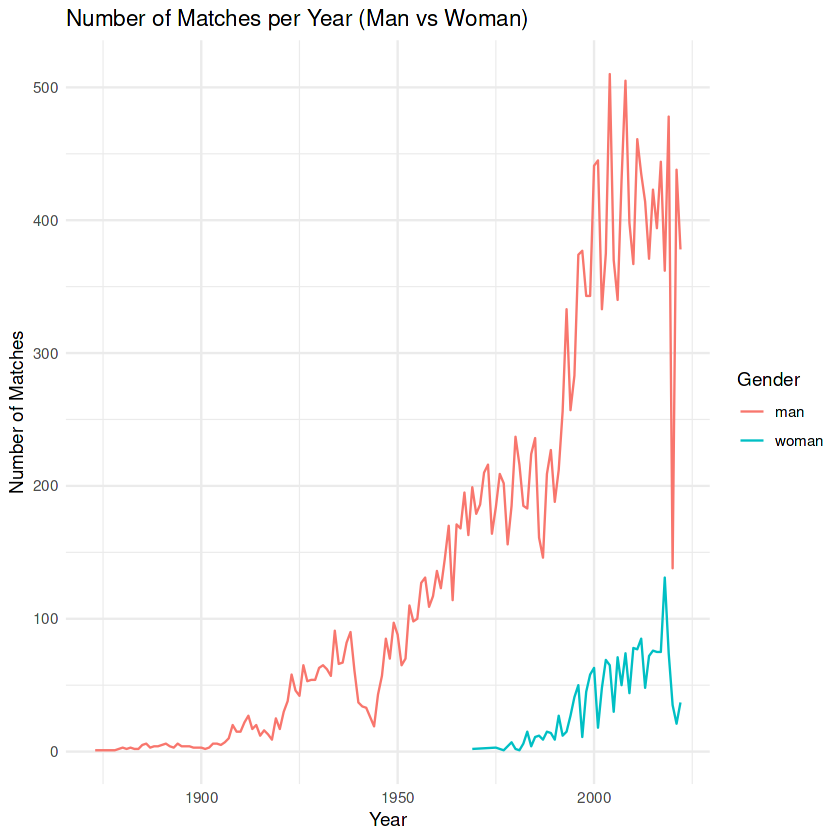

In [69]:
matches_per_year <- all %>%
    group_by(gender, year) %>%
    summarize(num_matches = n(), .groups = "drop")

ggplot(matches_per_year, aes(x = year, y = num_matches, color = gender)) +
    geom_line() +
    labs(
        title = "Number of Matches per Year (Man vs Woman)",
        x = "Year",
        y = "Number of Matches",
        color = "Gender"
    ) + 
    theme_minimal()

In [71]:
# Find top-scoring countries (men & women).
all %>%
    group_by(gender, home_team) %>%
    summarize(scores = sum(home_score), .groups = "drop") %>%
    arrange(gender, desc(scores)) %>%
    group_by(gender) %>%
    slice_head(n = 1)

gender,home_team,scores
<chr>,<chr>,<dbl>
man,Germany,786
woman,United States,278


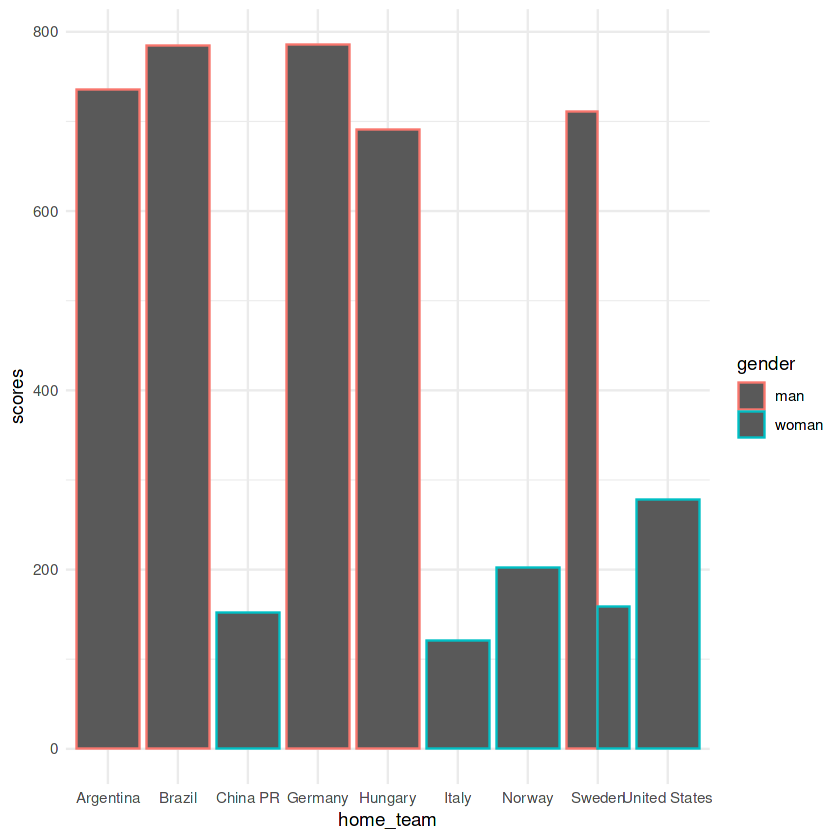

In [77]:
top_countries <- all %>%
    group_by(gender, home_team) %>%
    summarize(scores = sum(home_score), .groups = "drop") %>%
    arrange(gender, desc(scores)) %>%
    group_by(gender) %>%
    slice_head(n = 5)
ggplot(top_countries, aes(x = home_team, y = scores, color = gender)) + 
    # geom_col(position = "dodge")
    geom_bar(stat = "identity", position = "dodge") +
    theme_minimal()

In [81]:
unique(all$tournament)

[1] "Friendly"                                     
  [2] "British Home Championship"                    
  [3] "Évence Coppée Trophy"                         
  [4] "Copa Newton"                                  
  [5] "Copa Lipton"                                  
  [6] "Copa Premio Honor Argentino"                  
  [7] "Copa Premio Honor Uruguayo"                   
  [8] "Copa América"                                 
  [9] "Copa Roca"                                    
 [10] "Copa Chevallier Boutell"                      
 [11] "Nordic Championship"                          
 [12] "Central European International Cup"           
 [13] "Baltic Cup"                                   
 [14] "Balkan Cup"                                   
 [15] "FIFA World Cup"                               
 [16] "Copa Rio Branco"                              
 [17] "FIFA World Cup qualification"                 
 [18] "Bolivarian Games"                             
 [19] "CCCF Championship"                            
 [20] "NAFC Championship"                            
 [21] "Copa Oswaldo Cruz"                            
 [22] "Pan American Championship"                    
 [23] "Copa del Pacífico"                            
 [24] "Copa Bernardo O'Higgins"                      
 [25] "AFC Asian Cup qualification"                  
 [26] "Atlantic Cup"                                 
 [27] "AFC Asian Cup"                                
 [28] "African Cup of Nations"                       
 [29] "Copa Paz del Chaco"                           
 [30] "Merdeka Tournament"                           
 [31] "UEFA Euro qualification"                      
 [32] "UEFA Euro"                                    
 [33] "Windward Islands Tournament"                  
 [34] "African Cup of Nations qualification"         
 [35] "Vietnam Independence Cup"                     
 [36] "Copa Carlos Dittborn"                         
 [37] "Phillip Seaga Cup"                            
 [38] "CONCACAF Championship"                        
 [39] "Copa Juan Pinto Durán"                        
 [40] "Arab Cup"                                     
 [41] "South Pacific Games"                          
 [42] "CONCACAF Championship qualification"          
 [43] "Copa Artigas"                                 
 [44] "GaNEFo"                                       
 [45] "King's Cup"                                   
 [46] "Gulf Cup"                                     
 [47] "Indonesia Tournament"                         
 [48] "Korea Cup"                                    
 [49] "Palestine Cup"                                
 [50] "Brazil Independence Cup"                      
 [51] "Oceania Nations Cup"                          
 [52] "Copa Ramón Castilla"                          
 [53] "CECAFA Cup"                                   
 [54] "Kuneitra Cup"                                 
 [55] "Copa Félix Bogado"                            
 [56] "Real Madrid 75th Anniversary Cup"             
 [57] "Beijing International Friendship Tournament"  
 [58] "CFU Caribbean Cup qualification"              
 [59] "CFU Caribbean Cup"                            
 [60] "Amílcar Cabral Cup"                           
 [61] "Guangzhou International Friendship Tournament"
 [62] "Mundialito"                                   
 [63] "West African Cup"                             
 [64] "Nehru Cup"                                    
 [65] "Great Wall Cup"                               
 [66] "Merlion Cup"                                  
 [67] "UDEAC Cup"                                    
 [68] "Kirin Cup"                                    
 [69] "Lunar New Year Cup"                           
 [70] "Rous Cup"                                     
 [71] "Arab Cup qualification"                       
 [72] "Tournoi de France"                            
 [73] "Malta International Tournament"               
 [74] "Tournament Burkina Faso"                      
 [75] 

In [83]:
# Compare goals across tournament types 
all %>%
    group_by(gender, tournament) %>%
    filter(tournament %in% c("FIFA World Cup", "Continental Championships", "Friendly", "FIFA World Cup qualification")) %>%
    summarize(total_goals = sum(all_score),
             avg_goals = mean(all_score),
             var_goals = var(all_score),
             .groups = "drop") %>%
    arrange(desc(var_goals))

gender,tournament,total_goals,avg_goals,var_goals
<chr>,<chr>,<dbl>,<dbl>,<dbl>
woman,Friendly,207,4.500000,3.588889
man,Friendly,34530,3.937735,3.191378
woman,FIFA World Cup qualification,240,4.067797,3.064290
woman,FIFA World Cup,518,4.078740,2.946132
man,FIFA World Cup,1907,3.891837,2.767418
man,FIFA World Cup qualification,12235,3.778567,2.692071


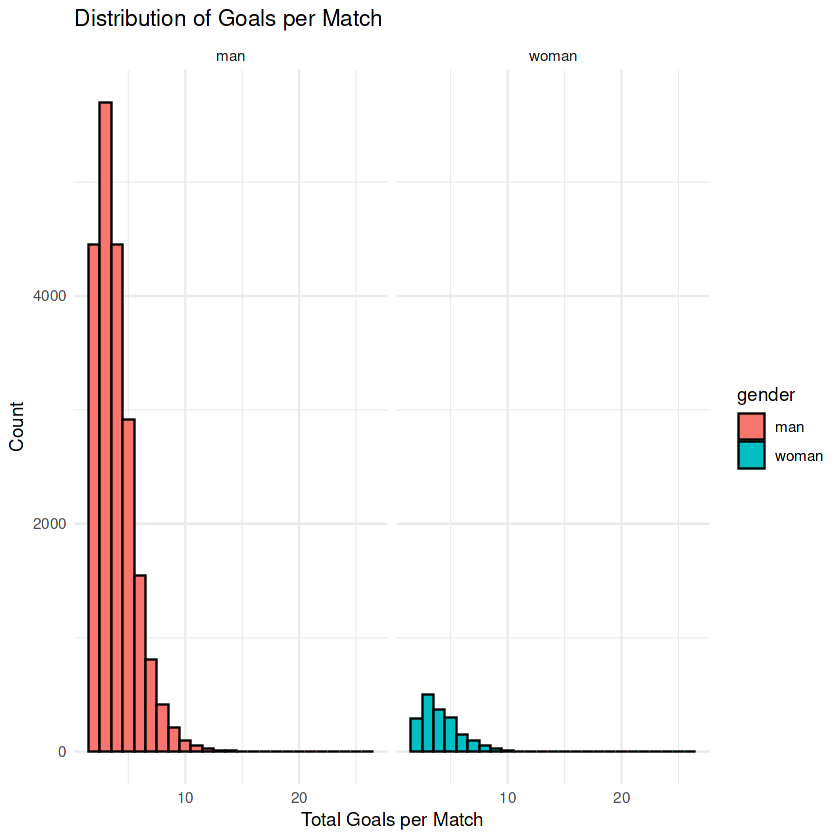

In [91]:
# Histogram: distribution of goals scored (men vs women).
ggplot(all, aes(x = all_score, fill = gender)) +
  geom_histogram(binwidth = 1, color = "black") +
  facet_wrap(~gender) +
  labs(
    title = "Distribution of Goals per Match",
    x = "Total Goals per Match",
    y = "Count"
  ) +
  theme_minimal()

In [92]:
head(man)

date,home_team,away_team,home_score,away_score,tournament,goal_diff,match_result,year,month,day,is_friendly,is_man,gender
<date>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>
1873-03-08,England,Scotland,4,2,Friendly,2,home_win,1873,3,8,1,1,man
1874-03-07,Scotland,England,2,1,Friendly,1,home_win,1874,3,7,1,1,man
1875-03-06,England,Scotland,2,2,Friendly,0,tie,1875,3,6,1,1,man
1877-03-03,England,Scotland,1,3,Friendly,2,away_win,1877,3,3,1,1,man
1878-03-02,Scotland,England,7,2,Friendly,5,home_win,1878,3,2,1,1,man
1879-01-18,England,Wales,2,1,Friendly,1,home_win,1879,1,18,1,1,man


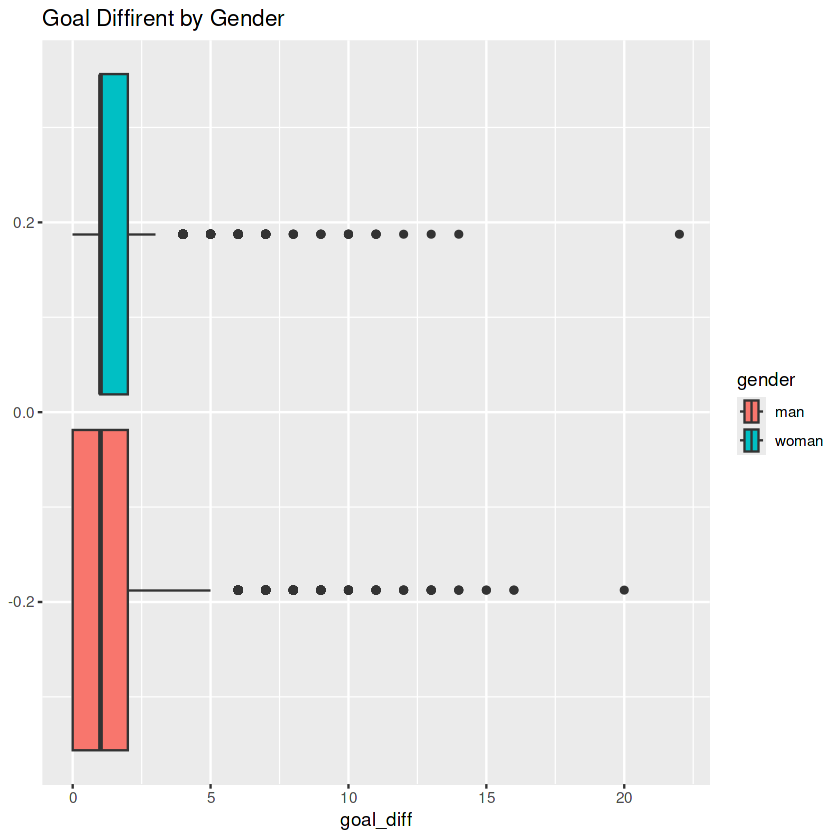

In [98]:
# Boxplot: goal_difference by gender.
ggplot(all, aes(x=goal_diff, fill=gender))+
    geom_boxplot()+
    labs(
        title = "Goal Diffirent by Gender",
    )

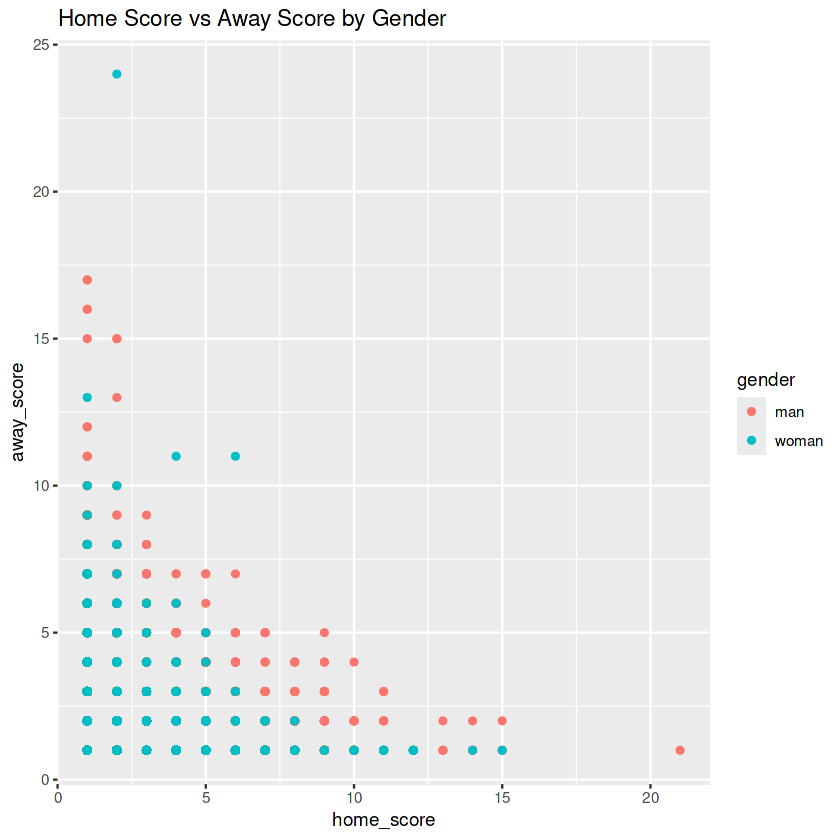

In [99]:
# Scatter plot: home_score vs away_score.
ggplot(all, aes(x=home_score, y=away_score, color=gender))+
    geom_point()+
    labs(
        title = "Home Score vs Away Score by Gender"
    )

In [102]:
library(corrplot)

corrplot 0.92 loaded



Warning message in text.default(pos.xlabel[, 1], pos.xlabel[, 2], newcolnames, srt = tl.srt, :
“"addcoef.col" is not a graphical parameter”
Warning message in text.default(pos.ylabel[, 1], pos.ylabel[, 2], newrownames, col = tl.col, :
“"addcoef.col" is not a graphical parameter”
Warning message in title(title, ...):
“"addcoef.col" is not a graphical parameter”


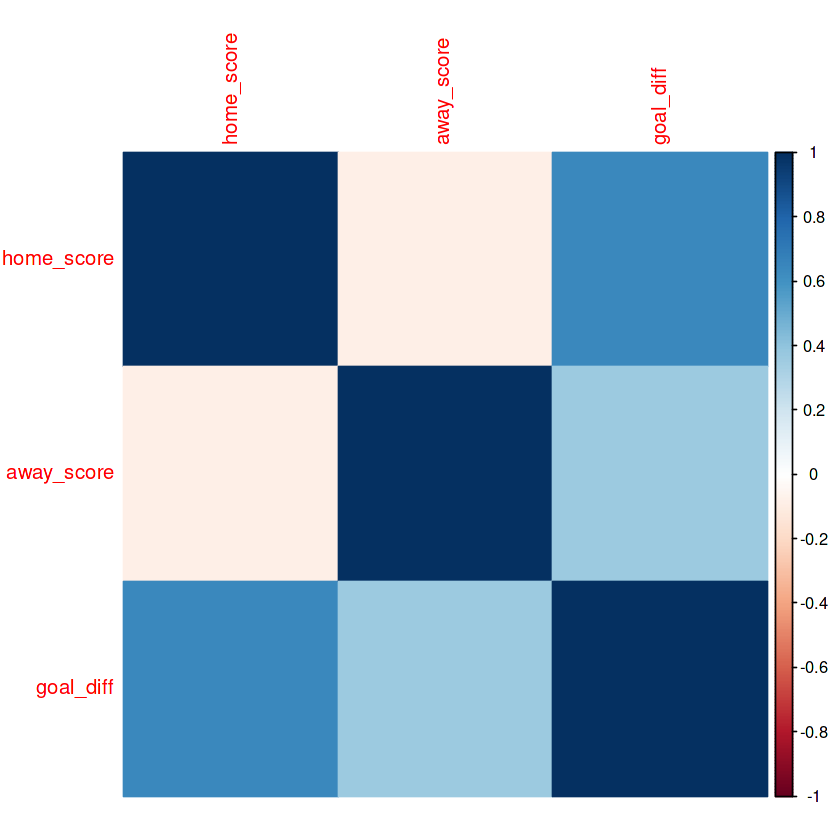

In [103]:
# Heatmap: correlation between variables (home_score, away_score, goal_difference)
cor_data <- all %>%
    select(home_score, away_score, goal_diff)
cor_matrix <- cor(cor_data, use = "complete.obs")

corrplot(cor_matrix, method = "color", addcoef.col="black", number.cex=1)

In [104]:
# Create a frequency table of match results.
table(all$match_result)


away_win home_win      tie 
    5986     9532     7023 

In [107]:
# Are average goals per match significantly different between men and women?
# Use t-test for:
#total goals
t_total <- t.test(all_score ~ gender, data = all)
#home_goal
t_home <- t.test(home_score ~ gender, data = all)
#away_goal 
t_away <- t.test(away_score ~ gender, data = all)

print("t_total")
print(t_total)
print('t_home')
print(t_home)
print("t_away")
print(t_away)

[1] "t_total"

	Welch Two Sample t-test

data:  all_score by gender
t = -6.4477, df = 2070.8, p-value = 1.409e-10
alternative hypothesis: true difference in means between group man and group woman is not equal to 0
95 percent confidence interval:
 -0.4046815 -0.2159211
sample estimates:
  mean in group man mean in group woman 
           3.912534            4.222835 

[1] "t_home"

	Welch Two Sample t-test

data:  home_score by gender
t = -4.228, df = 2048.1, p-value = 2.461e-05
alternative hypothesis: true difference in means between group man and group woman is not equal to 0
95 percent confidence interval:
 -0.25026382 -0.09166392
sample estimates:
  mean in group man mean in group woman 
           2.135710            2.306674 

[1] "t_away"

	Welch Two Sample t-test

data:  away_score by gender
t = -3.9414, df = 2014.7, p-value = 8.378e-05
alternative hypothesis: true difference in means between group man and group woman is not equal to 0
95 percent confidence interval:
 -0.208668

In [113]:
# Proportion test: Is home advantage stronger in men's or women's matches?
home_counts <- all %>%
    group_by(gender) %>%
    summarize(home_wins = sum(match_result == "home_win"),
             total_matches = n(), .groups = "drop"
             )
print(home_counts)
prop.test(
    x = home_counts$home_wins,
    n = home_counts$total_matches
)

# A tibble: 2 × 3
  gender home_wins total_matches
  <chr>      <int>         <int>
1 man         8702         20728
2 woman        830          1813



	2-sample test for equality of proportions with continuity correction

data:  home_counts$home_wins out of home_counts$total_matches
X-squared = 9.7021, df = 1, p-value = 0.001841
alternative hypothesis: two.sided
95 percent confidence interval:
 -0.06218329 -0.01378899
sample estimates:
   prop 1    prop 2 
0.4198186 0.4578047 
